# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import plot_temperature_triptych

In [2]:
steps = {
    0:  100,
    1:   99,
    2:   98,
    3:   96,
    4:   95,
    5:   94,
    6:   92,
    7:   90,
    8:   89,
    9:   87,
    10:  85,
    11:  83,
    12:  81,
    13:  79,
    14:  76,
    15:  74,
    16:  71,
    17:  68,
    18:  65,
    19:  61,
    20:  58,
    21:  54,
    22:  49,
    23:  44,
    24:  39,
    25:  33,
    26:  26,
    27:  19,
    28:  10,
    29:   1,
}

In [3]:
lam = 2
n_replicas = 2
n_samples = 1

swap_algorithm = {
	"p_ratio" : "p",
	"odd":   [ steps[0], steps[4], steps[8],  steps[12], steps[14], steps[16], steps[18], steps[20], steps[22]],
	"even":  [ steps[2], steps[6], steps[10], steps[13], steps[15], steps[17], steps[19], steps[21], steps[23]],
	"debug" : True
}

# Composed Dataset

 diff 1.0021815299987793


/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/toy/src/score_integral.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


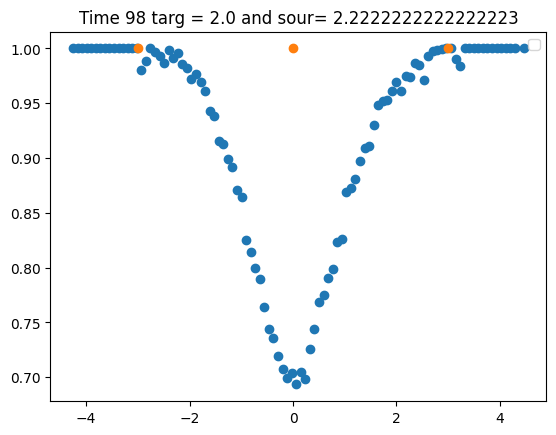

p ratio.         0.8104968667030334 std 0.27780479192733765
Time 98 swap btwn source 2.22 and target 2.00 accept 0.81 
 diff 1.041405439376831


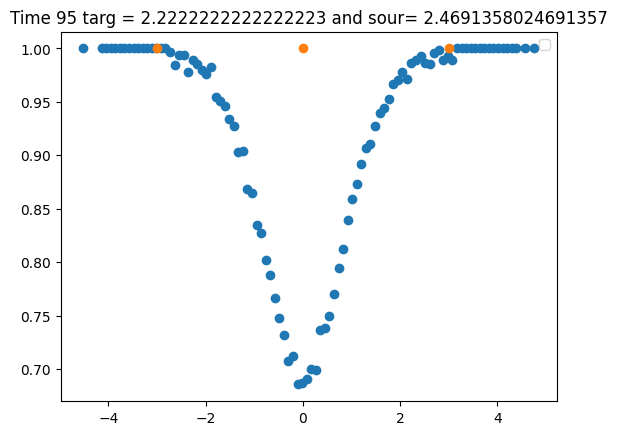

p ratio.         0.8110691905021667 std 0.2801682651042938
Time 95 swap btwn source 2.47 and target 2.22 accept 0.81 
 diff 1.097443699836731


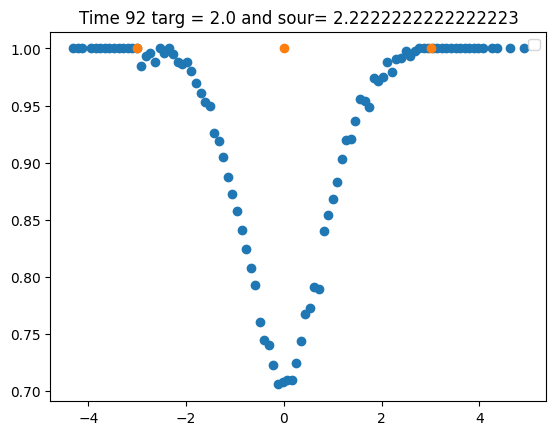

p ratio.         0.8256826400756836 std 0.2667427659034729
Time 92 swap btwn source 2.22 and target 2.00 accept 0.83 
 diff 1.2221860885620117


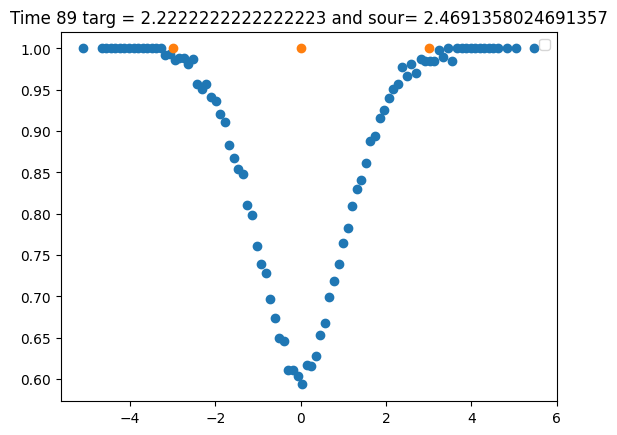

p ratio.         0.7584570646286011 std 0.33166858553886414
Time 89 swap btwn source 2.47 and target 2.22 accept 0.76 
 diff 1.3067152500152588


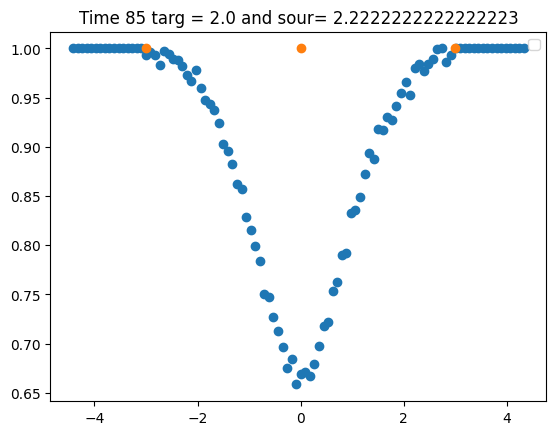

p ratio.         0.7954335808753967 std 0.29504090547561646
Time 85 swap btwn source 2.22 and target 2.00 accept 0.80 
 diff 1.5226558446884155


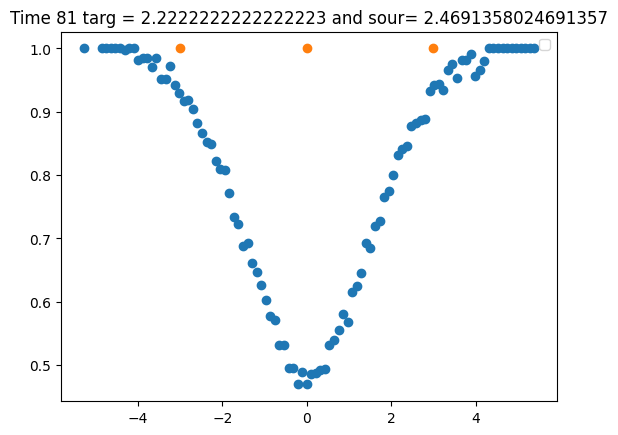

p ratio.         0.6523617506027222 std 0.3951379954814911
Time 81 swap btwn source 2.47 and target 2.22 accept 0.65 
 diff 1.4830100536346436


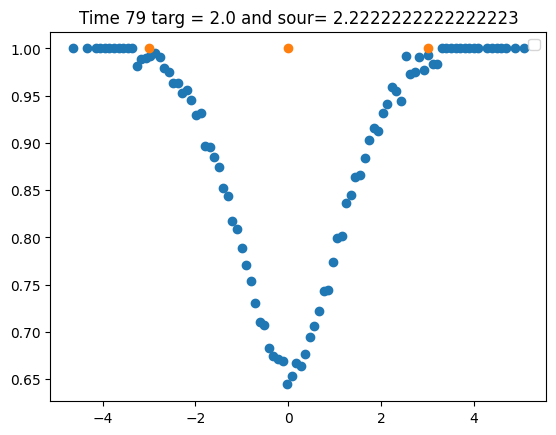

p ratio.         0.7706092596054077 std 0.30915161967277527
Time 79 swap btwn source 2.22 and target 2.00 accept 0.77 
 diff 1.6821612119674683


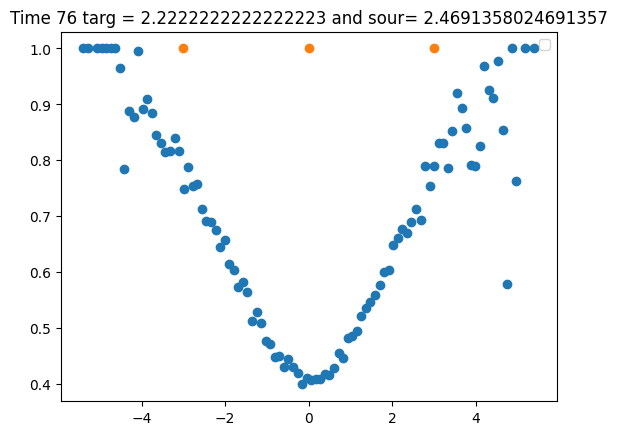

p ratio.         0.5388216376304626 std 0.4164702296257019
Time 76 swap btwn source 2.47 and target 2.22 accept 0.54 
 diff 1.602758526802063


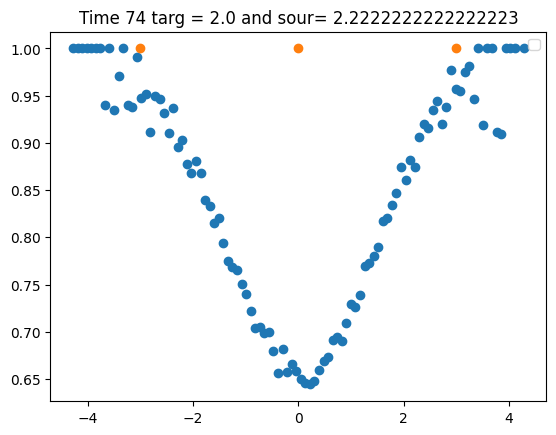

p ratio.         0.7347891330718994 std 0.3280642628669739
Time 74 swap btwn source 2.22 and target 2.00 accept 0.73 
 diff 1.8089396953582764


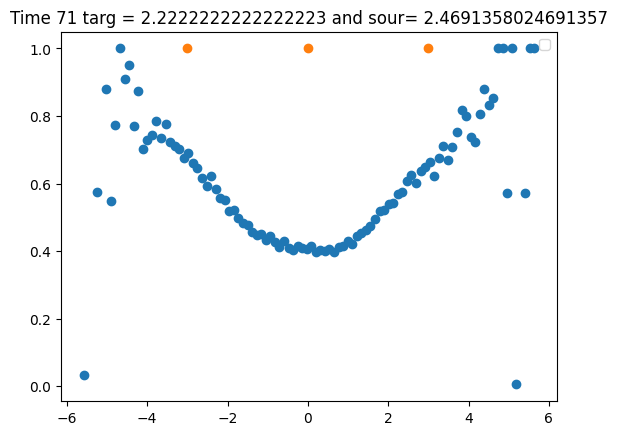

p ratio.         0.4885643720626831 std 0.4210604727268219
Time 71 swap btwn source 2.47 and target 2.22 accept 0.49 
 diff 1.7123726606369019


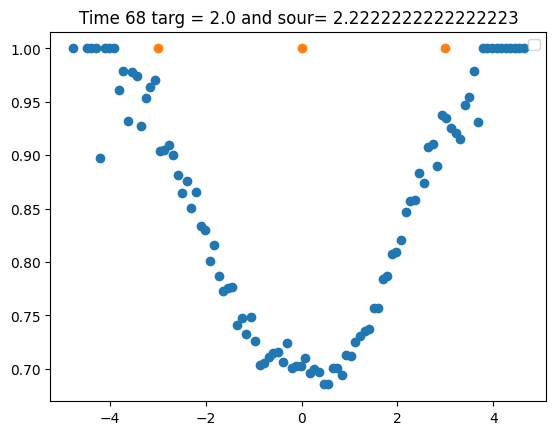

p ratio.         0.7462763786315918 std 0.3324725031852722
Time 68 swap btwn source 2.22 and target 2.00 accept 0.75 
 diff 1.9232405424118042


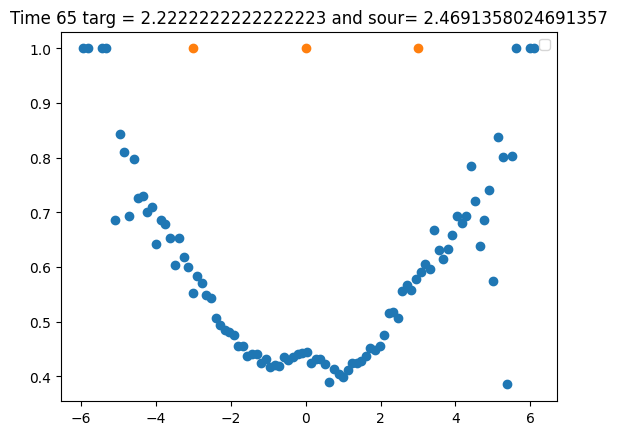

p ratio.         0.47288522124290466 std 0.42973792552948
Time 65 swap btwn source 2.47 and target 2.22 accept 0.47 
 diff 1.8029011487960815


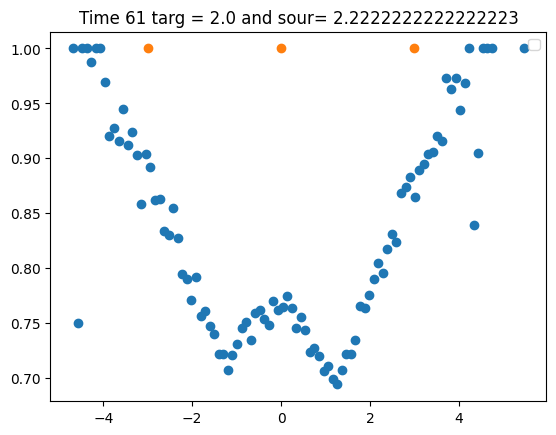

p ratio.         0.7587727308273315 std 0.3387739658355713
Time 61 swap btwn source 2.22 and target 2.00 accept 0.76 
 diff 2.0174176692962646


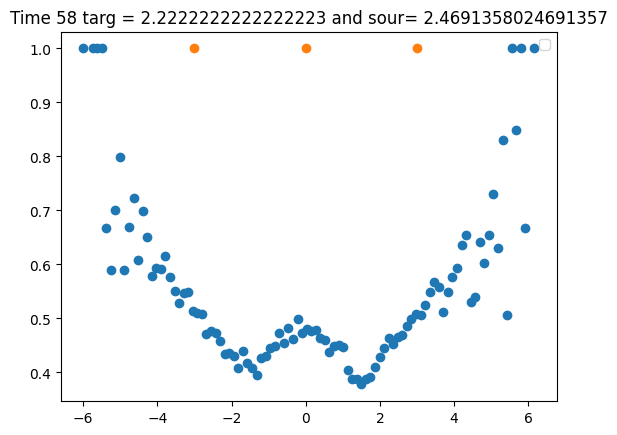

p ratio.         0.463680237531662 std 0.43636831641197205
Time 58 swap btwn source 2.47 and target 2.22 accept 0.46 
 diff 1.865214228630066


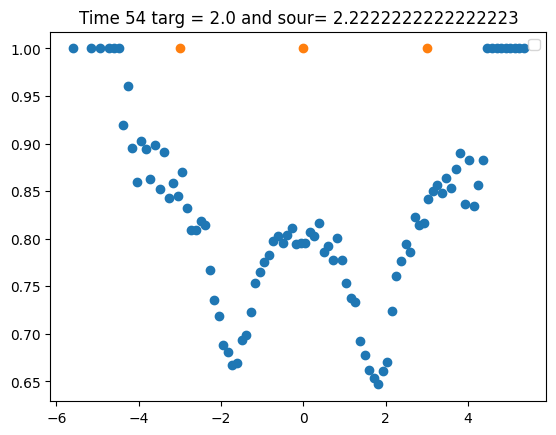

p ratio.         0.75669264793396 std 0.3331306576728821
Time 54 swap btwn source 2.22 and target 2.00 accept 0.76 
 diff 2.097264289855957


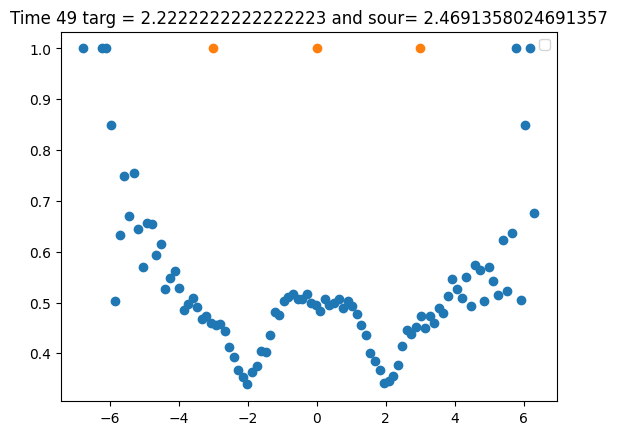

p ratio.         0.4550548791885376 std 0.4384329319000244
Time 49 swap btwn source 2.47 and target 2.22 accept 0.46 
 diff 1.9231054782867432


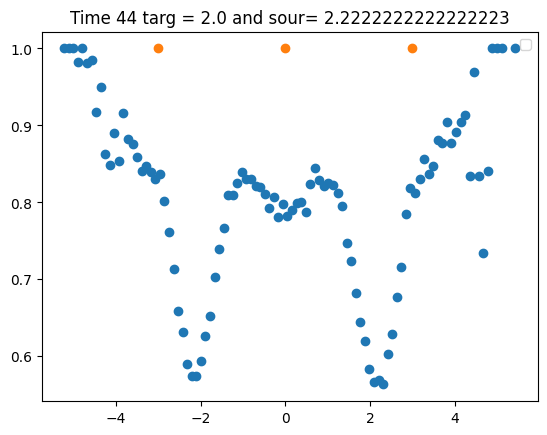

p ratio.         0.7377601861953735 std 0.33467212319374084
Time 44 swap btwn source 2.22 and target 2.00 accept 0.74 


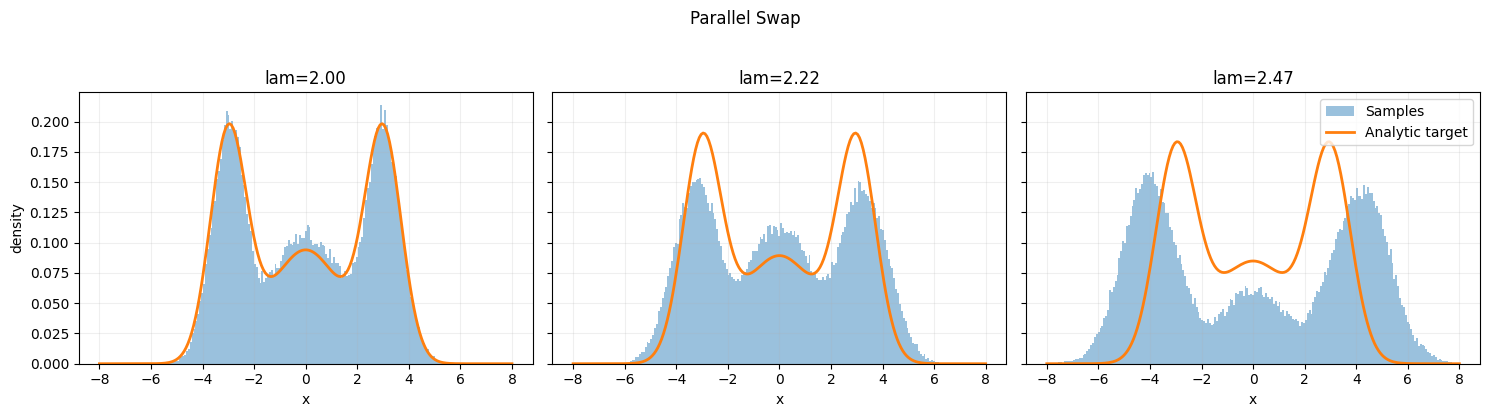

In [4]:
_ = plot_temperature_triptych(
	dataset_name="composed",
	lam=lam,
	n_samples=n_samples,
	n_replicas=n_replicas,
	replica_swaps=True,
	swap_algorithm=swap_algorithm,
)

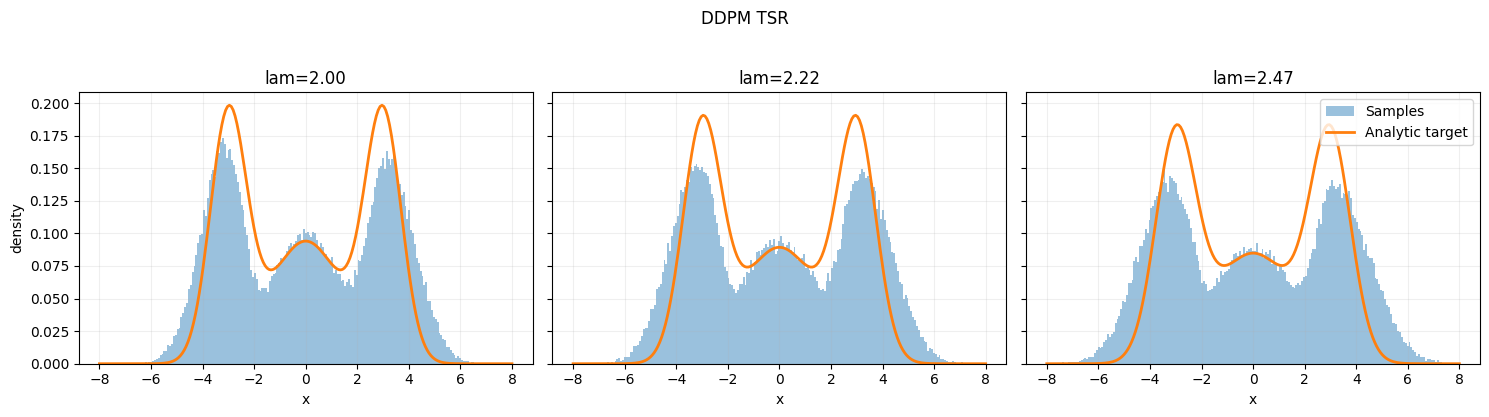

In [5]:
_ = plot_temperature_triptych(
	dataset_name="composed",
	lam=lam,
	n_samples=n_samples,
	n_replicas=n_replicas,
	replica_swaps=False,
	swap_algorithm=swap_algorithm
)

# MNIST Dataset

In [6]:
# _ = plot_temperature_triptych(
# 	dataset_name="mnist",
# 	k=0.5,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=False,
# 	swap_algorithm=swap_algorithm
# )

In [7]:
# _ = plot_temperature_triptych(
# 	dataset_name="mnist",
# 	k=2.0,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=False,
# 	swap_algorithm=swap_algorithm
# )

# Best of N

In [8]:
# _ = plot_temperature_triptych(
# 	dataset_name="composed",
# 	k=k,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=True,
# 	swap_algorithm=swap_algorithm,
# 	best_of_n_runs=4
# )